# Applied Statistics: PyMC

Submitting: Gilad Mizrahi

## Exploring the Data

In [8]:
import pymc as pm
import arviz as az
import statsmodels.api as sm
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = sm.datasets.get_rdataset("SAT", "mosaicData").data

REGIONS = {
    "Alabama": "East South Central",
    "Alaska": "Pacific",
    "Arizona": "Mountain",
    "Arkansas": "West South Central",
    "California": "Pacific",
    "Colorado": "Mountain",
    "Connecticut": "New England",
    "Delaware": "South Atlantic",
    "Florida": "South Atlantic",
    "Georgia": "South Atlantic",
    "Hawaii": "Pacific",
    "Idaho": "Mountain",
    "Illinois": "East North Central",
    "Indiana": "East North Central",
    "Iowa": "West North Central",
    "Kansas": "West North Central",
    "Kentucky": "East South Central",
    "Louisiana": "West South Central",
    "Maine": "New England",
    "Maryland": "South Atlantic",
    "Massachusetts": "New England",
    "Michigan": "East North Central",
    "Minnesota": "West North Central",
    "Mississippi": "East South Central",
    "Missouri": "West North Central",
    "Montana": "Mountain",
    "Nebraska": "West North Central",
    "Nevada": "Mountain",
    "New Hampshire": "New England",
    "New Jersey": "Middle Atlantic",
    "New Mexico": "Mountain",
    "New York": "Middle Atlantic",
    "North Carolina": "South Atlantic",
    "North Dakota": "West North Central",
    "Ohio": "East North Central",
    "Oklahoma": "West South Central",
    "Oregon": "Pacific",
    "Pennsylvania": "Middle Atlantic",
    "Rhode Island": "New England",
    "South Carolina": "South Atlantic",
    "South Dakota": "West North Central",
    "Tennessee": "East South Central",
    "Texas": "West South Central",
    "Utah": "Mountain",
    "Vermont": "New England",
    "Virginia": "South Atlantic",
    "Washington": "Pacific",
    "West Virginia": "South Atlantic",
    "Wisconsin": "East North Central",
    "Wyoming": "Mountain",
}

df.insert(1, "region", df["state"].map(REGIONS))

df

,state,region,expend,ratio,salary,frac,verbal,math,sat
0,Alabama,East South Central,4.405,17.2,31.144,8,491,538,1029
1,Alaska,Pacific,8.963,17.6,47.951,47,445,489,934
2,Arizona,Mountain,4.778,19.3,32.175,27,448,496,944
3,Arkansas,West South Central,4.459,17.1,28.934,6,482,523,1005
4,California,Pacific,4.992,24.0,41.078,45,417,485,902
5,Colorado,Mountain,5.443,18.4,34.571,29,462,518,980
6,Connecticut,New England,8.817,14.4,50.045,81,431,477,908
7,Delaware,South Atlantic,7.030,16.6,39.076,68,429,468,897
8,Florida,South Atlantic,5.718,19.1,32.588,48,420,469,889
9,Georgia,South Atlantic,5.193,16.3,32.291,65,406,448,854


In [9]:
df["region"].value_counts()

region
Mountain              8
South Atlantic        8
West North Central    7
New England           6
Pacific               5
East North Central    5
East South Central    4
West South Central    4
Middle Atlantic       3
Name: count, dtype: int64

In [10]:
df.describe()

,expend,ratio,salary,frac,verbal,math,sat
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,5.905260,16.858000,34.828920,35.240000,457.140000,508.780000,965.920000
std,1.362807,2.266355,5.941265,26.762417,35.175948,40.204726,74.820558
min,3.656000,13.800000,25.994000,4.000000,401.000000,443.000000,844.000000
25%,4.881750,15.225000,30.977500,9.000000,427.250000,474.750000,897.250000
50%,5.767500,16.600000,33.287500,28.000000,448.000000,497.500000,945.500000
75%,6.434000,17.575000,38.545750,63.000000,490.250000,539.500000,1032.000000
max,9.774000,24.300000,50.045000,81.000000,516.000000,592.000000,1107.000000


### **AI**,
* What is the SAT exam in one sentence?
* What are the possible exam scores? Give a percentile table.

### Answer

#### What is the SAT?
The SAT is a standardized, multiple-choice test used primarily by U.S. colleges to assess a high school student's readiness for higher education, covering Reading/Writing and Math.

#### Possible Scores
The SAT is scored on a scale of 400–1600, combining two section scores of 200–800 each:

* Evidence-Based Reading and Writing (EBRW): 200–800
* Math: 200–800

#### Approximate Percentile Table

| Composite Score | Approx. Percentile |
|---|---|
| 1600 | 99+ |
| 1500 | 98 |
| 1400 | 94 |
| 1300 | 87 |
| 1200 | 76 |
| 1100 | 62 |
| 1000 | 45 |
| 900 | 28 |
| 800 | 13 |
| 700 | 4 |




| Variable | Description                                                                                  |
|----------|----------------------------------------------------------------------------------------------|
| state    | a factor with names of each state                                                            |
| expend   | expenditure per pupil in average daily attendance in public elementary and secondary schools |
| ratio    | average pupil/teacher ratio in public elementary and secondary schools                       |
| salary   | estimated average annual salary of teachers in public elementary and secondary schools       |
| frac     | percentage of all eligible students taking the SAT                                           |
| verbal   | average verbal SAT score                                                                     |
| math     | average math SAT score                                                                       |
| sat      | average total SAT score                                                                      |

### Simpson's Paradox?

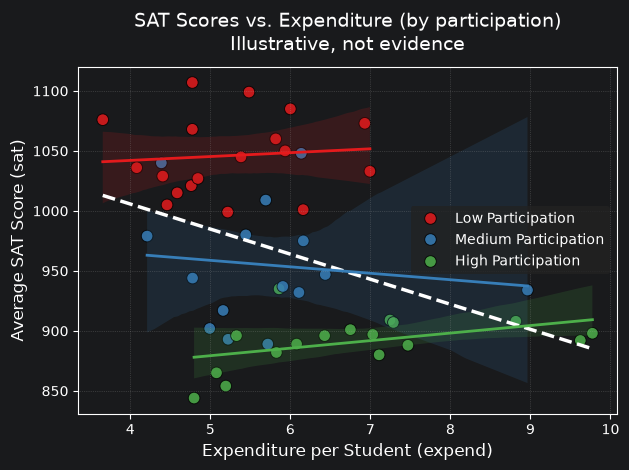

In [11]:
tiers = ["Low Participation", "Medium Participation", "High Participation"]

df["frac_tier"] = pd.qcut(df["frac"], q=3, labels=tiers)

# 1. Scatter points
sns.scatterplot(
    data=df,
    x="expend",
    y="sat",
    hue="frac_tier",
    palette="Set1",
    s=70,
    edgecolor="black",
    alpha=0.85,
)

# 2. Overall Naive Trend (No CI clutter)
sns.regplot(
    data=df,
    x="expend",
    y="sat",
    scatter=False,
    ci=None,
    line_kws={
        "linestyle": "--",
        "color": "white",
        "linewidth": 2.5,
        "label": "Pooled Trend (Naive)",
    },
)

# 3. Stratified Trends
colors = sns.color_palette("Set1", 3)

for tier, color in zip(tiers, colors):
    sns.regplot(
        data=df[df["frac_tier"] == tier],
        x="expend",
        y="sat",
        scatter=False,
        line_kws={"color": color, "linewidth": 2, "label": f"{tier} Trend"},
    )

plt.title(
    "SAT Scores vs. Expenditure (by participation)\nIllustrative, not evidence",
    fontsize=14,
    pad=12,
)
plt.xlabel("Expenditure per Student (expend)", fontsize=12)
plt.ylabel("Average SAT Score (sat)", fontsize=12)
plt.legend(frameon=True, facecolor="#222222", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

### AI,

* Can Simpson's paradox occur on a confounding variable that is not grouped/clustered?
* Show me the equation to when it actually happens

#### Answer

#### Yes — grouping is not required

Simpson's Paradox is often shown with categorical confounders (like your participation groups) because it's visually intuitive, but the mechanism is really about confounding/omitted-variable bias, which applies just as well to a continuous confounder. Grouping is just one special case (equivalent to using a categorical/dummy variable for the confounder).

#### The general equation

Suppose the true relationship between Y and X, controlling for confounder Z, is:

$$ Y = \beta_0 + \beta_1 X + \beta_2 Z + \varepsilon $$

If you ignore $Z$ and regress $Y$ on $X$ alone, the marginal (pooled) slope you estimate is:

$$ \beta_1^* = \beta_1 + \beta_2 \cdot \gamma $$

where $\gamma = \frac{\text{Cov}\left(X, Z\right)}{\text{Var}\left(X\right)}$ — i.e., the slope you'd get regressing $Z$ on $X$ (how strongly the confounder moves with $X$).

This is the classic omitted-variable bias formula.

#### When Simpson's Paradox (sign reversal) actually happens

The pooled slope $\beta_1^*$ flips sign relative to the true within-group slope $\beta_1$ when:

$\text{sgn}\left(\beta_2 \cdot \gamma\right) \neq \text{sgn}\left(\beta_1\right)$ AND $|\beta_2 \cdot \gamma| > |\beta_1|$

In words: the confounder's effect on $Y$ ($\beta_2$), amplified by how strongly it's correlated with $X$ ($\gamma$), has to be large enough and in the opposite direction to overpower and reverse the true effect.

In [16]:
corr_cols = ['sat', 'expend', 'frac']
marginal_corr = df[corr_cols].corr(method='pearson')
print("Marginal (Pearson) correlations:")
print(marginal_corr.round(3))

Marginal (Pearson) correlations:
          sat  expend   frac
sat     1.000  -0.381 -0.887
expend -0.381   1.000  0.593
frac   -0.887   0.593  1.000


`sat-expend` is negative, but does not correlate strongly . `frac` strongly correlates with `expend` and `sat`

In [13]:
def partial_corr(df, x, y, control):
    """Partial correlation between x and y, controlling for `control` (single covariate)."""
    # Residualize x on control
    slope_x, intercept_x, *_ = stats.linregress(df[control], df[x])
    resid_x = df[x] - (slope_x * df[control] + intercept_x)

    # Residualize y on control
    slope_y, intercept_y, *_ = stats.linregress(df[control], df[y])
    resid_y = df[y] - (slope_y * df[control] + intercept_y)

    r, p = stats.pearsonr(resid_x, resid_y)
    return r, p

r_partial, p_partial = partial_corr(df, x='expend', y='sat', control='frac')
r_marginal, p_marginal = stats.pearsonr(df['expend'], df['sat'])

summary = pd.DataFrame({
    'Correlation type': ['Marginal (sat vs expend)', 'Partial (sat vs expend | frac)'],
    'r': [r_marginal, r_partial],
    'p-value': [p_marginal, p_partial],
})
print(summary.round(4))

                 Correlation type       r  p-value
0        Marginal (sat vs expend) -0.3805   0.0064
1  Partial (sat vs expend | frac)  0.3906   0.0050


In [14]:
naive = sm.OLS(df['sat'], sm.add_constant(df[['expend']])).fit()
adjusted = sm.OLS(df['sat'], sm.add_constant(df[['expend', 'frac']])).fit()

print(f"Naive expend coef:    {naive.params['expend']:.3f}  (p={naive.pvalues['expend']:.3f})")
print(f"Adjusted expend coef: {adjusted.params['expend']:.3f}  (p={adjusted.pvalues['expend']:.3f})")

Naive expend coef:    -20.892  (p=0.006)
Adjusted expend coef: 12.287  (p=0.006)


#### In Our Case
$ \beta_1^* = -20.892, \beta_1 = 12.287 \implies \beta_2 \cdot \gamma = -33.179 $